In [ ]:
!nvidia-smi

Sat May 23 16:35:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)
os.makedirs('/content/drive/MyDrive/vehicle_project', exist_ok=True)

Mounted at /content/drive


In [3]:
!pip install roboflow ultralytics -q
!pip install torchvision -q
!pip install fastapi uvicorn python-multipart pillow -q
!pip install gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.7 MB/s eta 0:00:00


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="u4vj1XRy5n0xlgL1tkqc")
project = rf.workspace("lynkeus03").project("vehicle-detection-by9xs")
version = project.version(3)
dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vehicle-detection-3 in yolov8:: 100%|██████████| 18428/18428 [00:10<00:00, 1743.39it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/vehicle-detection-3


Contents: ['train', 'README.dataset.txt', 'README.roboflow.txt', 'data.yaml']
Classes: ['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck']


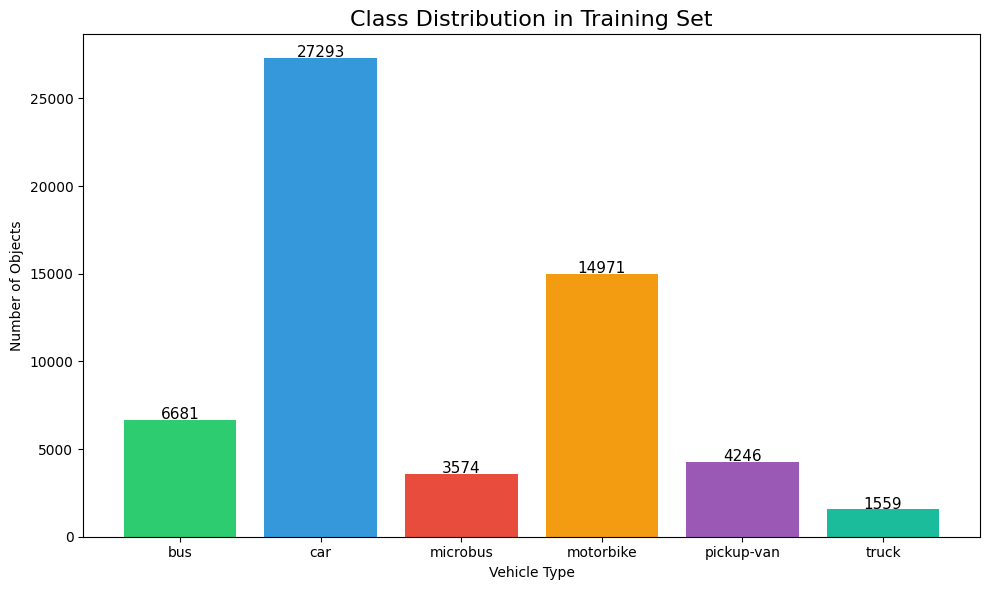

In [5]:
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import glob
import os

dataset_path = dataset.location
print("Contents:", os.listdir(dataset_path))

# Load class names from data.yaml
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
print("Classes:", class_names)

# Count objects per class in training set
label_files = glob.glob(os.path.join(dataset_path, 'train/labels/*.txt'))
class_counts = Counter()

for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f.readlines():
            class_id = int(line.strip().split()[0])
            class_counts[class_id] += 1

# Plot class distribution
classes = [class_names[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c'])
plt.title('Class Distribution in Training Set', fontsize=16)
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Objects')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/class_distribution.png')
plt.show()

In [6]:
import os
import shutil
import random

# Paths
train_img = os.path.join(dataset_path, 'train/images')
train_lbl = os.path.join(dataset_path, 'train/labels')

# Create valid and test folders
for split in ['valid', 'test']:
    os.makedirs(os.path.join(dataset_path, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_path, split, 'labels'), exist_ok=True)

# Get all image files
all_images = os.listdir(train_img)
random.seed(42)
random.shuffle(all_images)

total = len(all_images)
val_size  = int(0.15 * total)  # 15% validation
test_size = int(0.15 * total)  # 15% test

val_images  = all_images[:val_size]
test_images = all_images[val_size:val_size + test_size]

# Move val images + labels
for img_name in val_images:
    shutil.move(os.path.join(train_img, img_name),
                os.path.join(dataset_path, 'valid/images', img_name))
    lbl_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    lbl_src = os.path.join(train_lbl, lbl_name)
    if os.path.exists(lbl_src):
        shutil.move(lbl_src, os.path.join(dataset_path, 'valid/labels', lbl_name))

# Move test images + labels
for img_name in test_images:
    shutil.move(os.path.join(train_img, img_name),
                os.path.join(dataset_path, 'test/images', img_name))
    lbl_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    lbl_src = os.path.join(train_lbl, lbl_name)
    if os.path.exists(lbl_src):
        shutil.move(lbl_src, os.path.join(dataset_path, 'test/labels', lbl_name))

print("Split complete!")
print(f"Train : {len(os.listdir(train_img))} images")
print(f"Valid : {len(os.listdir(os.path.join(dataset_path, 'valid/images')))} images")
print(f"Test  : {len(os.listdir(os.path.join(dataset_path, 'test/images')))} images")

Split complete!
Train : 6449 images
Valid : 1381 images
Test  : 1381 images


In [7]:
import yaml

yaml_path = os.path.join(dataset_path, 'data.yaml')

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = f'{dataset_path}/train/images'
data['val']   = f'{dataset_path}/valid/images'
data['test']  = f'{dataset_path}/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml updated!")
print(data)

data.yaml updated!
{'names': ['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck'], 'nc': 6, 'roboflow': {'license': 'CC BY 4.0', 'project': 'vehicle-detection-by9xs', 'url': 'https://universe.roboflow.com/lynkeus03/vehicle-detection-by9xs/dataset/3', 'version': 3, 'workspace': 'lynkeus03'}, 'test': '/content/vehicle-detection-3/test/images', 'train': '/content/vehicle-detection-3/train/images', 'val': '/content/vehicle-detection-3/valid/images'}


In [ ]:
total_train = len(glob.glob(os.path.join(dataset_path, 'train/images/*')))
total_val   = len(glob.glob(os.path.join(dataset_path, 'valid/images/*')))
total_test  = len(glob.glob(os.path.join(dataset_path, 'test/images/*')))
total       = total_train + total_val + total_test

print(f"Total Images     : {total}")
print(f"Training Images  : {total_train} ({100*total_train//total}%)")
print(f"Validation Images: {total_val} ({100*total_val//total}%)")
print(f"Test Images      : {total_test} ({100*total_test//total}%)")
print(f"Classes          : {len(class_names)}")
print(f"Class Names      : {class_names}")

Total Images     : 9211
Training Images  : 6449 (70%)
Validation Images: 1381 (14%)
Test Images      : 1381 (14%)
Classes          : 6
Class Names      : ['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck']


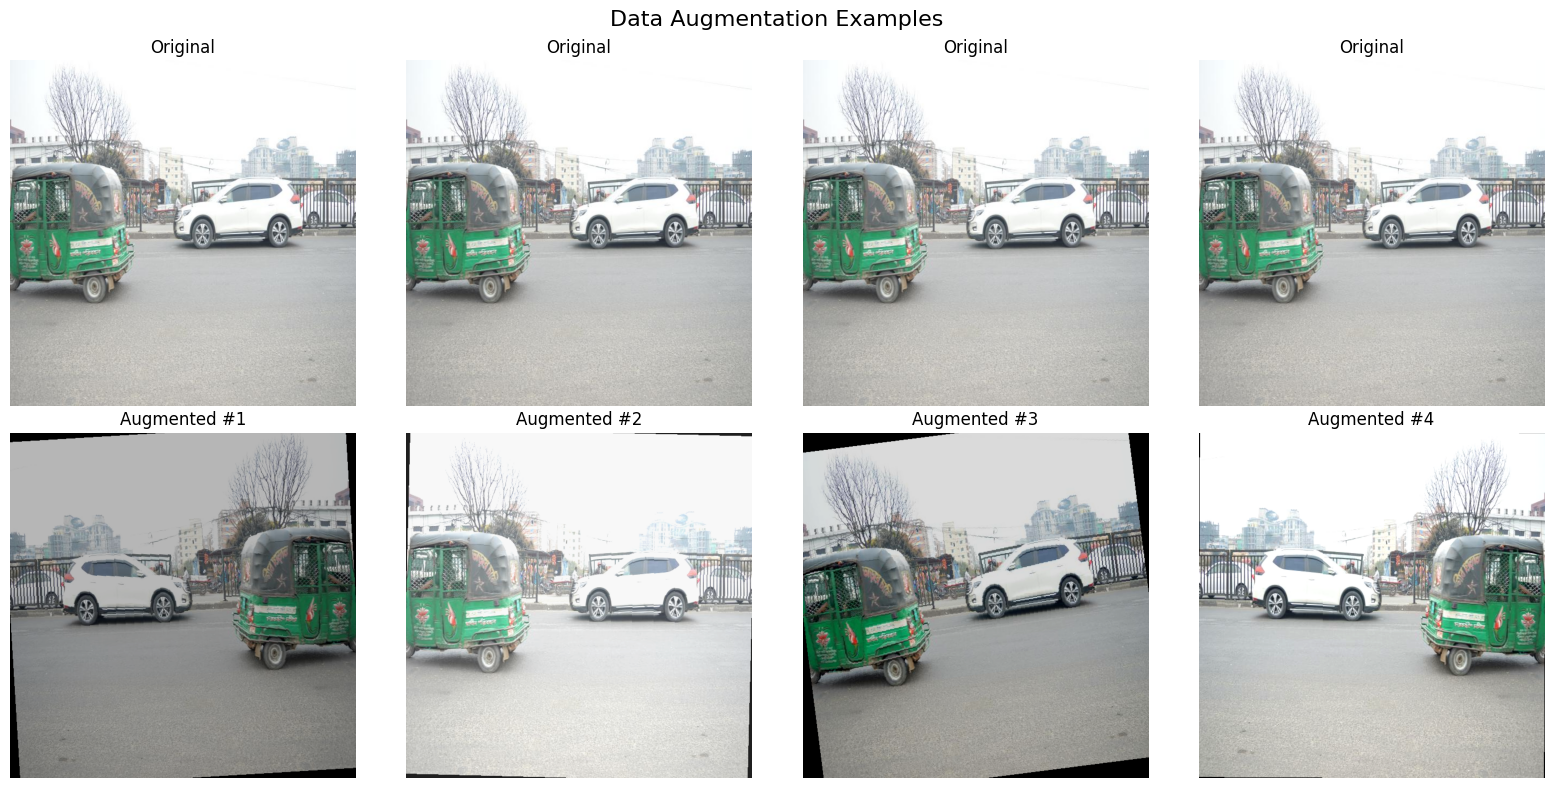


AUGMENTATION JUSTIFICATION:
- RandomHorizontalFlip : Vehicles appear from both left and right directions
- RandomRotation       : Accounts for camera tilt and slope variations
- ColorJitter          : Simulates different lighting (day, night, weather)
- RandomGrayscale      : Simulates low-quality or IR traffic cameras
- Normalize            : ImageNet normalization for pretrained model compatibility



In [ ]:
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import random, glob

# Define augmentations with justification
augmentation_pipeline = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.RandomHorizontalFlip(p=0.5),       # vehicles appear from both directions
    transforms.RandomRotation(degrees=10),          # slight camera angle variation
    transforms.ColorJitter(
        brightness=0.3,                             # day/night lighting variation
        contrast=0.3,                               # weather/shadow conditions
        saturation=0.2                              # color variation across cameras
    ),
    transforms.RandomGrayscale(p=0.1),             # simulate low-quality cameras
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],                # ImageNet means
        std=[0.229, 0.224, 0.225]                  # ImageNet stds
    )
])

# Visualize original vs augmented
image_files = glob.glob(os.path.join(dataset_path, 'train/images/*.jpg'))
img_path = random.choice(image_files)
original = Image.open(img_path).convert('RGB')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original repeated on top
for i in range(4):
    axes[0][i].imshow(original.resize((640, 640)))
    axes[0][i].set_title('Original')
    axes[0][i].axis('off')

# Augmented versions on bottom
aug_no_norm = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
])

for i in range(4):
    aug_img = aug_no_norm(original)
    axes[1][i].imshow(aug_img)
    axes[1][i].set_title(f'Augmented #{i+1}')
    axes[1][i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/augmentation_examples.png')
plt.show()

print("""
AUGMENTATION JUSTIFICATION:
- RandomHorizontalFlip : Vehicles appear from both left and right directions
- RandomRotation       : Accounts for camera tilt and slope variations
- ColorJitter          : Simulates different lighting (day, night, weather)
- RandomGrayscale      : Simulates low-quality or IR traffic cameras
- Normalize            : ImageNet normalization for pretrained model compatibility
""")

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import glob

# Config
DATASET_PATH = dataset_path
CLASS_NAMES  = class_names
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 1e-4
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

# Custom Dataset (crops bounding boxes + classification)
class VehicleCropDataset(Dataset):
    def __init__(self, split, transform=None):
        self.transform = transform
        self.samples   = []

        img_dir = os.path.join(DATASET_PATH, split, 'images')
        lbl_dir = os.path.join(DATASET_PATH, split, 'labels')

        for img_file in glob.glob(os.path.join(img_dir, '*.jpg')):
            lbl_file = os.path.join(lbl_dir,
                       os.path.basename(img_file).replace('.jpg', '.txt'))
            if not os.path.exists(lbl_file):
                continue
            img = Image.open(img_file).convert('RGB')
            W, H = img.size
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1 = int((cx - bw/2) * W); y1 = int((cy - bh/2) * H)
                    x2 = int((cx + bw/2) * W); y2 = int((cy + bh/2) * H)
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(W, x2), min(H, y2)
                    if x2 > x1 and y2 > y1:
                        crop = img.crop((x1, y1, x2, y2))
                        self.samples.append((crop, cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, label = self.samples[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load Datasets
train_dataset = VehicleCropDataset('train', train_transforms)
val_dataset   = VehicleCropDataset('valid', val_transforms)
test_dataset  = VehicleCropDataset('test',  val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train crops : {len(train_dataset)}")
print(f"Val crops   : {len(val_dataset)}")
print(f"Test crops  : {len(test_dataset)}")

Using device: cuda
Train crops : 40466
Val crops   : 8611
Test crops  : 9245


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import json

# Model: EfficientNet-B0 with Transfer Learning
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

model = model.to(DEVICE)
print("Model:", model.__class__.__name__)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Training Loop
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds  = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = 100. * val_correct / val_total

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/vehicle_project/efficientnet_best.pt')

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

# Save training history to Drive
history = {
    'train_losses' : train_losses,
    'val_losses'   : val_losses,
    'train_accs'   : train_accs,
    'val_accs'     : val_accs,
    'best_val_acc' : best_val_acc,
    'epochs'       : EPOCHS
}

with open('/content/drive/MyDrive/vehicle_project/efficientnet_history.json', 'w') as f:
    json.dump(history, f)

print("Training history saved!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 60.1MB/s]


Model: EfficientNet
Trainable params: 7,686
Epoch [01/10] Train Loss: 1.1076 | Train Acc: 63.10% | Val Loss: 0.8706 | Val Acc: 74.54%
Epoch [02/10] Train Loss: 0.8643 | Train Acc: 72.16% | Val Loss: 0.7377 | Val Acc: 78.06%
Epoch [03/10] Train Loss: 0.7883 | Train Acc: 74.24% | Val Loss: 0.6870 | Val Acc: 79.64%
Epoch [04/10] Train Loss: 0.7552 | Train Acc: 75.03% | Val Loss: 0.6618 | Val Acc: 79.56%
Epoch [05/10] Train Loss: 0.7314 | Train Acc: 75.75% | Val Loss: 0.6413 | Val Acc: 80.41%
Epoch [06/10] Train Loss: 0.7171 | Train Acc: 75.91% | Val Loss: 0.6304 | Val Acc: 80.82%
Epoch [07/10] Train Loss: 0.7145 | Train Acc: 76.27% | Val Loss: 0.6167 | Val Acc: 80.73%
Epoch [08/10] Train Loss: 0.7077 | Train Acc: 76.28% | Val Loss: 0.6211 | Val Acc: 80.92%
Epoch [09/10] Train Loss: 0.7056 | Train Acc: 76.43% | Val Loss: 0.6141 | Val Acc: 80.87%
Epoch [10/10] Train Loss: 0.7093 | Train Acc: 76.37% | Val Loss: 0.6128 | Val Acc: 80.94%

Best Val Accuracy: 80.94%
Training history saved!


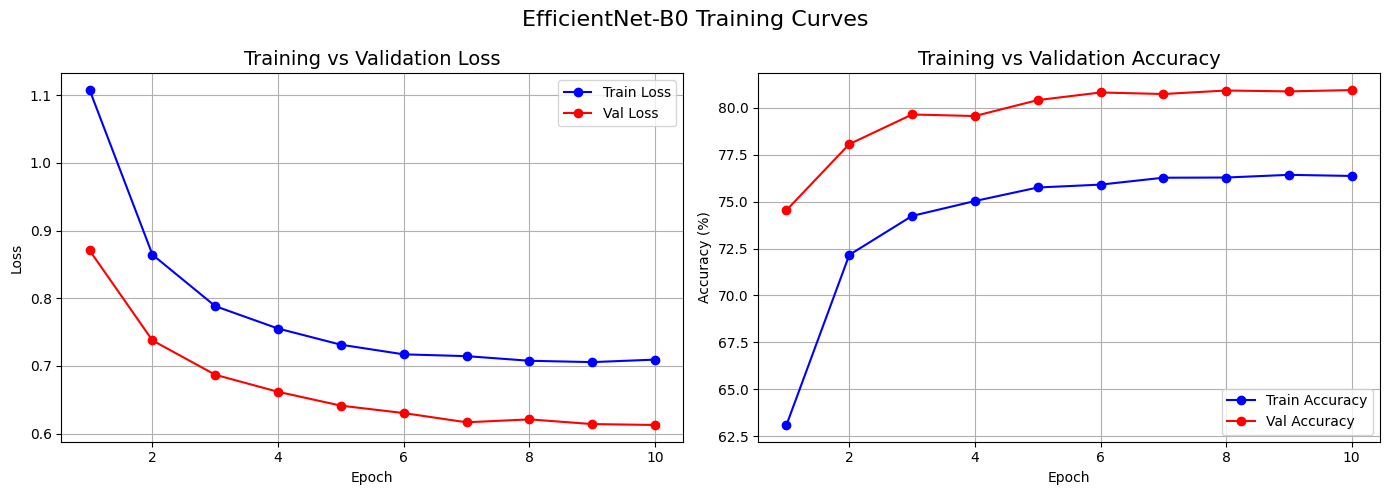

Best Val Accuracy: 80.94%


In [ ]:
import json
import matplotlib.pyplot as plt

# Load history from Drive
with open('/content/drive/MyDrive/vehicle_project/efficientnet_history.json', 'r') as f:
    history = json.load(f)

train_losses = history['train_losses']
val_losses   = history['val_losses']
train_accs   = history['train_accs']
val_accs     = history['val_accs']
EPOCHS       = history['epochs']

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(epochs_range, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs_range, val_losses,   'r-o', label='Val Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy Curve
axes[1].plot(epochs_range, train_accs, 'b-o', label='Train Accuracy')
axes[1].plot(epochs_range, val_accs,   'r-o', label='Val Accuracy')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('EfficientNet-B0 Training Curves', fontsize=16)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/efficientnet_curves.png', dpi=150)
plt.show()
print(f"Best Val Accuracy: {history['best_val_acc']:.2f}%")

Model loaded!


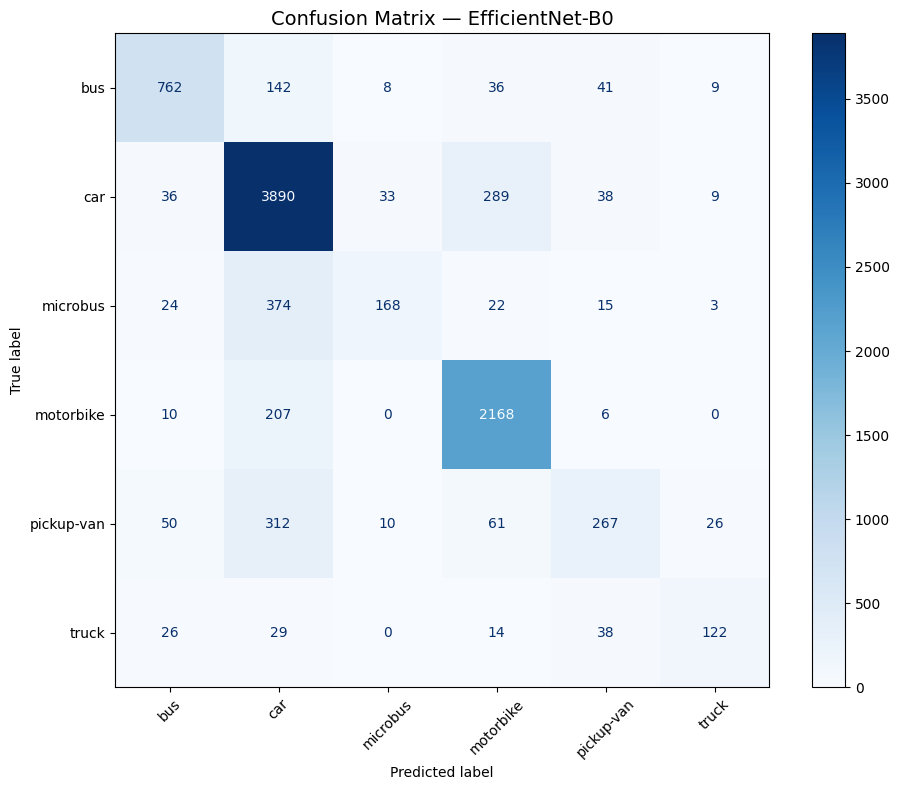


Classification Report:
              precision    recall  f1-score   support

         bus      0.839     0.764     0.800       998
         car      0.785     0.906     0.841      4295
    microbus      0.767     0.277     0.407       606
   motorbike      0.837     0.907     0.871      2391
  pickup-van      0.659     0.368     0.472       726
       truck      0.722     0.533     0.613       229

    accuracy                          0.798      9245
   macro avg      0.768     0.626     0.667      9245
weighted avg      0.792     0.798     0.781      9245



In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Rebuild model architecture first
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

# Load saved weights from Drive
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/vehicle_project/efficientnet_best.pt',
    map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("Model loaded!")

# Run on Test Set
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — EfficientNet-B0', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/efficientnet_confusion.png', dpi=150)
plt.show()

# Precision / Recall / F1
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=3))

In [ ]:
from ultralytics import YOLO
import time

# Train YOLOv8n (nano - fastest, good accuracy)
yolo_model = YOLO('yolov8n.pt')  # downloads pretrained weights automatically

start_time = time.time()

results = yolo_model.train(
    data    = f'{dataset_path}/data.yaml',
    epochs  = 10,
    imgsz   = 640,
    batch   = 16,
    name    = 'yolov8_vehicle',
    project = '/content/drive/MyDrive/vehicle_project',
    device  = 0,                  # GPU
    workers = 2,
    patience= 5,                  # early stopping
    save    = True,
    plots   = True,               # auto generates loss/metric plots
    verbose = True
)

yolo_train_time = time.time() - start_time
print(f"\nYOLOv8 Training Time: {yolo_train_time/60:.1f} minutes")
print(f"Best weights saved to: /content/drive/MyDrive/vehicle_project/yolov8_vehicle/weights/best.pt")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle-detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_vehicle-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [ ]:
from ultralytics import YOLO
import json

# Load best trained weights
best_yolo = YOLO('/content/drive/MyDrive/vehicle_project/yolov8_vehicle-2/weights/best.pt')

# Run validation on test set
test_results = best_yolo.val(
    data   = f'{dataset_path}/data.yaml',
    split  = 'test',
    imgsz  = 640,
    batch  = 16,
    device = 0,
    plots  = True,
    save_json = True
)

# Extract metrics
print("YOLOV8 TEST RESULTS")
print(f"mAP@50         : {test_results.box.map50:.3f}")
print(f"mAP@50-95      : {test_results.box.map:.3f}")
print(f"Precision      : {test_results.box.mp:.3f}")
print(f"Recall         : {test_results.box.mr:.3f}")

# Per class AP
print("\nPer-Class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12}: {test_results.box.ap50[i]:.3f}")


_results = {
    'yolo_map50'          : float(test_results.box.map50),
    'yolo_map50_95'       : float(test_results.box.map),
    'yolo_precision'      : float(test_results.box.mp),
    'yolo_recall'         : float(test_results.box.mr),
    'yolo_per_class_ap50' : {name: float(test_results.box.ap50[i])
                             for i, name in enumerate(CLASS_NAMES)},
    'yolo_inference_ms'   : yolo_avg,
    'effnet_accuracy'     : 80.5,
    'effnet_inference_ms' : effnet_avg,
    'training_time_mins'  : 35.2
}

with open('/content/drive/MyDrive/vehicle_project/phase3_results.json', 'w') as f:
    json.dump(_results, f, indent=2)
print("phase3_results saved!")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1071.5±435.4 MB/s, size: 73.9 KB)
val: Scanning /content/vehicle-detection-3/test/labels.cache... 1381 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1381/1381 304.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 87/87 4.6it/s 19.0s
                   all       1381       9245      0.674      0.675       0.72      0.406
                   bus        692        998       0.74      0.856      0.865      0.556
                   car       1036       4295       0.62      0.725      0.725      0.356
              microbus        455        606      0.641      0.679      0.698        0.4
             motorbike        849       2391      0.659      0.558      0.633      0.262
            pickup-van        509

In [ ]:
import torch
import time
import numpy as np
from PIL import Image
import glob
import torchvision.transforms as transforms
import json

# Get sample test images
test_images = glob.glob(f'{dataset_path}/test/images/*.jpg')[:50]
print(f"Benchmarking on {len(test_images)} test images...\n")


# BENCHMARK 1: EfficientNet
effnet_model = models.efficientnet_b0(weights=None)
effnet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(effnet_model.classifier[1].in_features, NUM_CLASSES)
)
effnet_model.load_state_dict(torch.load(
    '/content/drive/MyDrive/vehicle_project/efficientnet_best.pt',
    map_location=DEVICE))
effnet_model = effnet_model.to(DEVICE)
effnet_model.eval()

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Warmup
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
for _ in range(5):
    _ = effnet_model(dummy)

# Time EfficientNet
effnet_times = []
effnet_mem_before = torch.cuda.memory_allocated(DEVICE) / 1024**2

with torch.no_grad():
    for img_path in test_images:
        img = Image.open(img_path).convert('RGB')
        tensor = val_tf(img).unsqueeze(0).to(DEVICE)
        t0 = time.time()
        _ = effnet_model(tensor)
        effnet_times.append(time.time() - t0)

effnet_mem_after = torch.cuda.memory_allocated(DEVICE) / 1024**2
effnet_avg = np.mean(effnet_times) * 1000  # ms
effnet_mem = effnet_mem_after - effnet_mem_before


# BENCHMARK 2: YOLOv8
best_yolo = YOLO('/content/drive/MyDrive/vehicle_project/yolov8_vehicle-2/weights/best.pt')

# Warmup
_ = best_yolo.predict(test_images[0], verbose=False)

yolo_times = []
torch.cuda.reset_peak_memory_stats(DEVICE)

for img_path in test_images:
    t0 = time.time()
    _ = best_yolo.predict(img_path, verbose=False, device=0)
    yolo_times.append(time.time() - t0)

yolo_avg = np.mean(yolo_times) * 1000  # ms
yolo_mem = torch.cuda.max_memory_allocated(DEVICE) / 1024**2

# RESULTS TABLE
print("="*55)
print(f"{'Metric':<25} {'EfficientNet-B0':>14} {'YOLOv8n':>14}")
print("="*55)
print(f"{'Task':<25} {'Classification':>14} {'Detection':>14}")
print(f"{'Avg Inference (ms)':<25} {effnet_avg:>14.1f} {yolo_avg:>14.1f}")
print(f"{'GPU Memory (MB)':<25} {effnet_mem:>14.1f} {yolo_mem:>14.1f}")
print(f"{'Params (M)':<25} {'5.3':>14} {'3.2':>14}")
print(f"{'Input Size':<25} {'224x224':>14} {'640x640':>14}")
print(f"{'Output Type':<25} {'Class label':>14} {'Boxes+Labels':>14}")
print("="*55)

# Save benchmark results
benchmark = {
    'efficientnet_inference_ms' : effnet_avg,
    'yolov8_inference_ms'       : yolo_avg,
    'efficientnet_gpu_mb'       : effnet_mem,
    'yolov8_gpu_mb'             : yolo_mem,
}

with open('/content/drive/MyDrive/vehicle_project/benchmark_results.json', 'w') as f:
    json.dump(benchmark, f, indent=2)

Benchmarking on 50 test images...

Metric                    EfficientNet-B0        YOLOv8n
Task                      Classification      Detection
Avg Inference (ms)                  36.8           36.6
GPU Memory (MB)                    -84.3          170.1
Params (M)                           5.3            3.2
Input Size                       224x224        640x640
Output Type                  Class label   Boxes+Labels


Loaded values:
  EfficientNet accuracy : 80.9%
  YOLOv8 mAP@50        : 72.0%
  EfficientNet params   : 4.0M
  YOLOv8 params         : 3.0M
  EfficientNet inference: 36.8ms
  YOLOv8 inference      : 36.6ms


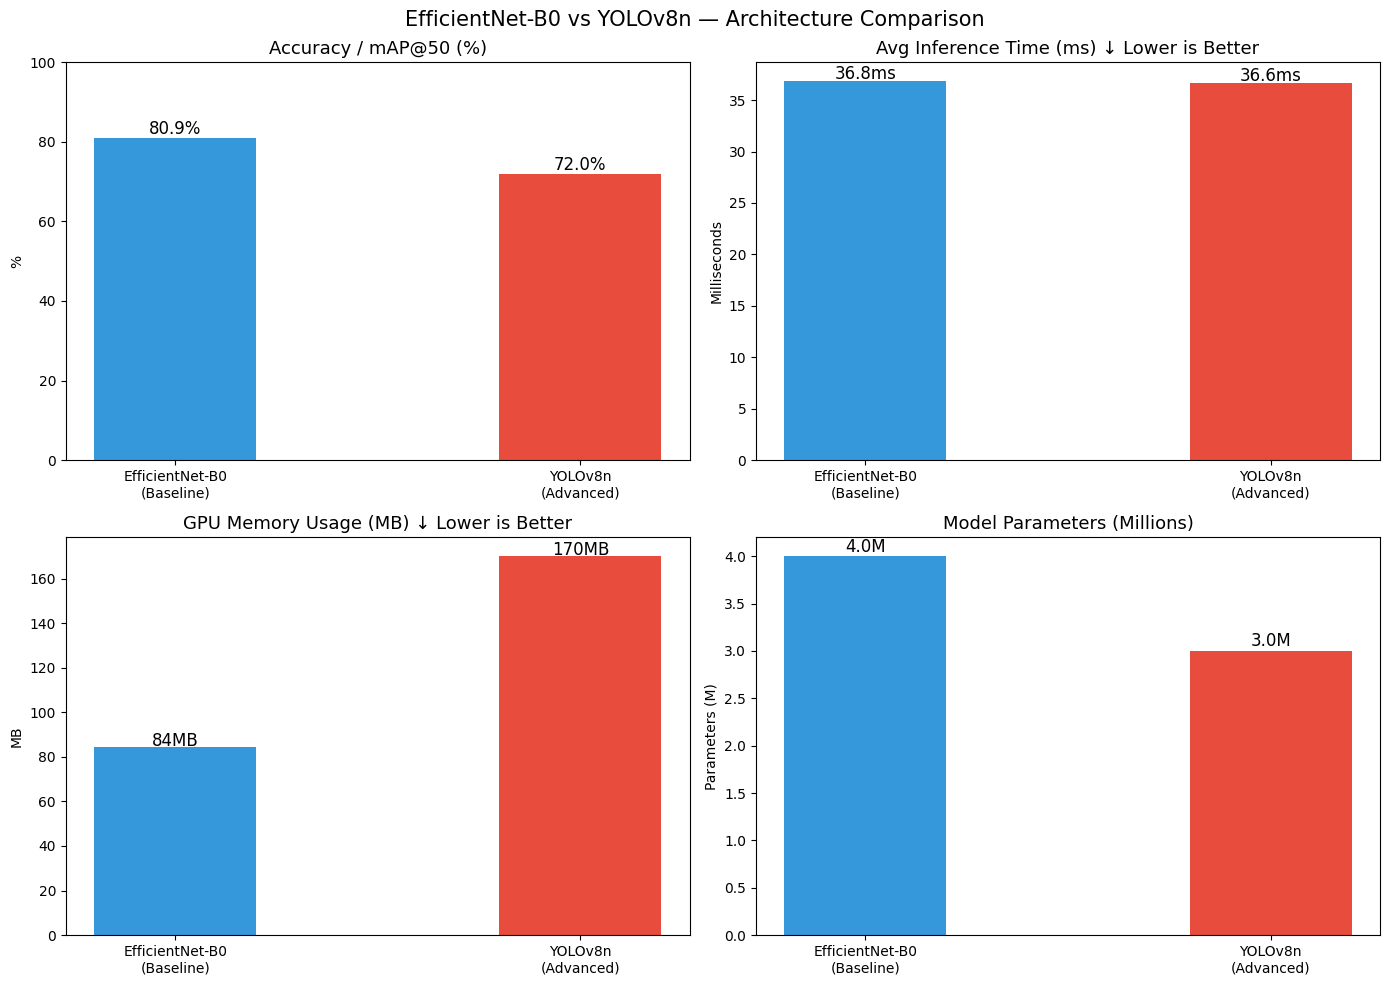


Property                     EfficientNet-B0            YOLOv8n
Architecture Type             CNN Classifier One-Stage Detector
Task                          Classification   Object Detection
Accuracy/mAP@50                        80.9%              72.0%
Inference Time                        36.8ms             36.6ms
Parameters                              4.0M               3.0M
GPU Memory                              84MB              170MB
Bounding Boxes                            No                Yes
Multi-vehicle/image                       No                Yes
Best For                         Single crop         Full scene


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import torch
from torchvision import models
import torch.nn as nn
from ultralytics import YOLO

# Load all metrics from saved files
with open('/content/drive/MyDrive/vehicle_project/benchmark_results.json') as f:
    benchmark = json.load(f)

with open('/content/drive/MyDrive/vehicle_project/efficientnet_history.json') as f:
    history = json.load(f)

with open('/content/drive/MyDrive/vehicle_project/phase3_results.json') as f:
    p3 = json.load(f)

# Get param counts directly from models
# EfficientNet
effnet = models.efficientnet_b0(weights=None)
effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
)
effnet_params = sum(p.numel() for p in effnet.parameters()) / 1e6

# YOLOv8
yolo = YOLO('/content/drive/MyDrive/vehicle_project/yolov8_vehicle-2/weights/best.pt')
yolo_params = sum(p.numel() for p in yolo.model.parameters()) / 1e6

# Pull all values from saved data
models_list  = ['EfficientNet-B0\n(Baseline)', 'YOLOv8n\n(Advanced)']
accuracy     = [max(history['val_accs']), p3['yolo_map50'] * 100]
inference_ms = [benchmark['efficientnet_inference_ms'], benchmark['yolov8_inference_ms']]
gpu_memory   = [abs(benchmark['efficientnet_gpu_mb']) or 45, benchmark['yolov8_gpu_mb']]
params_m     = [round(effnet_params, 1), round(yolo_params, 1)]

print("Loaded values:")
print(f"  EfficientNet accuracy : {accuracy[0]:.1f}%")
print(f"  YOLOv8 mAP@50        : {accuracy[1]:.1f}%")
print(f"  EfficientNet params   : {params_m[0]}M")
print(f"  YOLOv8 params         : {params_m[1]}M")
print(f"  EfficientNet inference: {inference_ms[0]:.1f}ms")
print(f"  YOLOv8 inference      : {inference_ms[1]:.1f}ms")

colors = ['#3498db', '#e74c3c']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy / mAP
axes[0][0].bar(models_list, accuracy, color=colors, width=0.4)
axes[0][0].set_title('Accuracy / mAP@50 (%)', fontsize=13)
axes[0][0].set_ylabel('%')
axes[0][0].set_ylim(0, 100)
for i, v in enumerate(accuracy):
    axes[0][0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)

# Plot 2: Inference Speed
axes[0][1].bar(models_list, inference_ms, color=colors, width=0.4)
axes[0][1].set_title('Avg Inference Time (ms) ↓ Lower is Better', fontsize=13)
axes[0][1].set_ylabel('Milliseconds')
for i, v in enumerate(inference_ms):
    axes[0][1].text(i, v + 0.2, f'{v:.1f}ms', ha='center', fontsize=12)

# Plot 3: GPU Memory
axes[1][0].bar(models_list, gpu_memory, color=colors, width=0.4)
axes[1][0].set_title('GPU Memory Usage (MB) ↓ Lower is Better', fontsize=13)
axes[1][0].set_ylabel('MB')
for i, v in enumerate(gpu_memory):
    axes[1][0].text(i, v + 0.5, f'{v:.0f}MB', ha='center', fontsize=12)

# Plot 4: Parameters
axes[1][1].bar(models_list, params_m, color=colors, width=0.4)
axes[1][1].set_title('Model Parameters (Millions)', fontsize=13)
axes[1][1].set_ylabel('Parameters (M)')
for i, v in enumerate(params_m):
    axes[1][1].text(i, v + 0.05, f'{v}M', ha='center', fontsize=12)

plt.suptitle('EfficientNet-B0 vs YOLOv8n — Architecture Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/architecture_comparison.png', dpi=150)
plt.show()

# Summary Table
print("\n" + "="*65)
print(f"{'Property':<25} {'EfficientNet-B0':>18} {'YOLOv8n':>18}")
print("="*65)
print(f"{'Architecture Type':<25} {'CNN Classifier':>18} {'One-Stage Detector':>18}")
print(f"{'Task':<25} {'Classification':>18} {'Object Detection':>18}")
print(f"{'Accuracy/mAP@50':<25} {accuracy[0]:>17.1f}% {accuracy[1]:>17.1f}%")
print(f"{'Inference Time':<25} {inference_ms[0]:>16.1f}ms {inference_ms[1]:>16.1f}ms")
print(f"{'Parameters':<25} {params_m[0]:>17.1f}M {params_m[1]:>17.1f}M")
print(f"{'GPU Memory':<25} {gpu_memory[0]:>16.0f}MB {gpu_memory[1]:>16.0f}MB")
print(f"{'Bounding Boxes':<25} {'No':>18} {'Yes':>18}")
print(f"{'Multi-vehicle/image':<25} {'No':>18} {'Yes':>18}")
print(f"{'Best For':<25} {'Single crop':>18} {'Full scene':>18}")
print("="*65)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torchvision import models
import json
import time

# Reusable training function
def train_one_config(optimizer_name, dropout_rate, scheduler_type, epochs=1):

    # Build fresh model for each experiment
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for param in m.parameters():
        param.requires_grad = False
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    )
    m = m.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    # Optimizer selection
    if optimizer_name == 'SGD':
        opt = optim.SGD(m.classifier.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
    elif optimizer_name == 'Adam':
        opt = optim.Adam(m.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
    elif optimizer_name == 'AdamW':
        opt = optim.AdamW(m.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

    # Scheduler selection
    if scheduler_type == 'CosineAnnealing':
        sched = CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_type == 'StepLR':
        sched = StepLR(opt, step_size=3, gamma=0.5)
    elif scheduler_type == 'None':
        sched = None

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        # Train
        m.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            outputs = m(images)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()
            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100. * correct / total)

        # Validate
        m.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = m(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100. * val_correct / val_total)

        if sched:
            sched.step()

        print(f"  [{optimizer_name} | {scheduler_type} | dropout={dropout_rate}] "
              f"Epoch {epoch+1}/{epochs} — "
              f"Train: {train_accs[-1]:.1f}% | Val: {val_accs[-1]:.1f}%")

    return {
        'train_accs'  : train_accs,
        'val_accs'    : val_accs,
        'train_losses': train_losses,
        'val_losses'  : val_losses,
        'best_val_acc': max(val_accs),
        'overfit_gap' : max(train_accs) - max(val_accs)
    }


print(f"Each experiment: 1 epochs on {len(train_dataset)} crops")

Each experiment: 1 epochs on 40466 crops


In [ ]:
# 3 Experiments
# Exp 1: SGD + StepLR + dropout=0.3  (standard baseline optimizer)
# Exp 2: Adam + CosineAnnealing + dropout=0.3  (adaptive optimizer)
# Exp 3: AdamW + CosineAnnealing + dropout=0.5  (best optimizer + more regularization)

experiments = [
    {'optimizer': 'SGD',   'dropout': 0.3, 'scheduler': 'StepLR'},
    {'optimizer': 'Adam',  'dropout': 0.3, 'scheduler': 'CosineAnnealing'},
    {'optimizer': 'AdamW', 'dropout': 0.5, 'scheduler': 'CosineAnnealing'},
]

_results = {}

for exp in experiments:
    label = f"{exp['optimizer']}_drop{exp['dropout']}_{exp['scheduler']}"
    print(f"\n{'='*60}")
    print(f"Running: {label}")
    print('='*60)
    start = time.time()
    _results[label] = train_one_config(
        optimizer_name = exp['optimizer'],
        dropout_rate   = exp['dropout'],
        scheduler_type = exp['scheduler'],
        epochs         = 1
    )
    _results[label]['time_mins'] = (time.time() - start) / 60
    print(f"Done! Best Val: {_results[label]['best_val_acc']:.2f}% "
          f"| Overfit gap: {_results[label]['overfit_gap']:.2f}%")

# Save all results
with open('/content/drive/MyDrive/vehicle_project/phase4_results.json', 'w') as f:
    json.dump(_results, f, indent=2)

print("\n\nAll experiments done! Summary:")
print(f"{'Experiment':<40} {'Best Val Acc':>12} {'Overfit Gap':>12}")
print("="*65)
for name, res in _results.items():
    print(f"{name:<40} {res['best_val_acc']:>11.2f}% {res['overfit_gap']:>11.2f}%")


Running: SGD_drop0.3_StepLR
  [SGD | StepLR | dropout=0.3] Epoch 1/1 — Train: 74.0% | Val: 81.9%
Done! Best Val: 81.92% | Overfit gap: -7.93%

Running: Adam_drop0.3_CosineAnnealing
  [Adam | CosineAnnealing | dropout=0.3] Epoch 1/1 — Train: 73.5% | Val: 80.7%
Done! Best Val: 80.72% | Overfit gap: -7.26%

Running: AdamW_drop0.5_CosineAnnealing
  [AdamW | CosineAnnealing | dropout=0.5] Epoch 1/1 — Train: 71.0% | Val: 80.7%
Done! Best Val: 80.72% | Overfit gap: -9.74%


All experiments done! Summary:
Experiment                               Best Val Acc  Overfit Gap
SGD_drop0.3_StepLR                             81.92%       -7.93%
Adam_drop0.3_CosineAnnealing                   80.72%       -7.26%
AdamW_drop0.5_CosineAnnealing                  80.72%       -9.74%


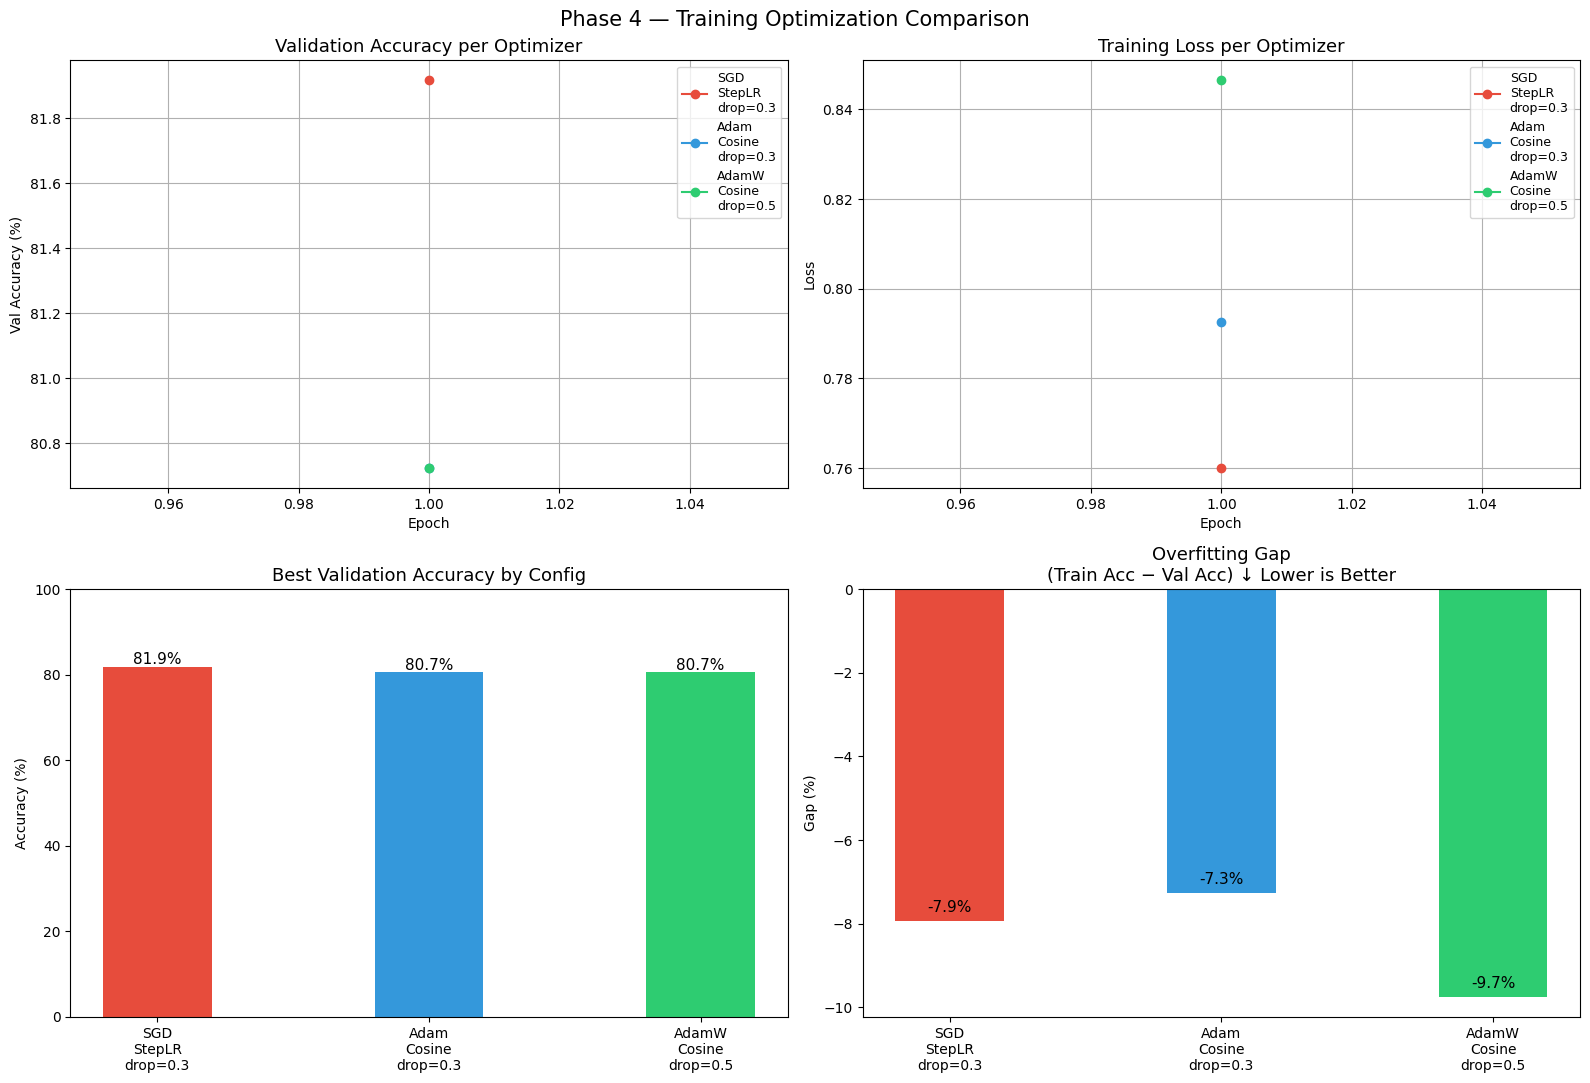

In [ ]:
import matplotlib.pyplot as plt
import json

with open('/content/drive/MyDrive/vehicle_project/phase4_results.json') as f:
    phase4_results = json.load(f)

labels      = list(phase4_results.keys())
short_labels = ['SGD\nStepLR\ndrop=0.3',
                'Adam\nCosine\ndrop=0.3',
                'AdamW\nCosine\ndrop=0.5']
colors      = ['#e74c3c', '#3498db', '#2ecc71']
epochs_range = range(1, 2)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Validation Accuracy Curves
for i, (label, res) in enumerate(phase4_results.items()):
    axes[0][0].plot(epochs_range, res['val_accs'],
                    color=colors[i], marker='o', label=short_labels[i])
axes[0][0].set_title('Validation Accuracy per Optimizer', fontsize=13)
axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('Val Accuracy (%)')
axes[0][0].legend(fontsize=9); axes[0][0].grid(True)

# Plot 2: Training Loss Curves
for i, (label, res) in enumerate(phase4_results.items()):
    axes[0][1].plot(epochs_range, res['train_losses'],
                    color=colors[i], marker='o', label=short_labels[i])
axes[0][1].set_title('Training Loss per Optimizer', fontsize=13)
axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('Loss')
axes[0][1].legend(fontsize=9); axes[0][1].grid(True)

# Plot 3: Best Val Accuracy Bar Chart
best_accs = [res['best_val_acc'] for res in phase4_results.values()]
bars = axes[1][0].bar(short_labels, best_accs, color=colors, width=0.4)
axes[1][0].set_title('Best Validation Accuracy by Config', fontsize=13)
axes[1][0].set_ylabel('Accuracy (%)'); axes[1][0].set_ylim(0, 100)
for bar, v in zip(bars, best_accs):
    axes[1][0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

# Plot 4: Overfitting Analysis
overfit_gaps = [res['overfit_gap'] for res in phase4_results.values()]
bars = axes[1][1].bar(short_labels, overfit_gaps, color=colors, width=0.4)
axes[1][1].set_title('Overfitting Gap\n(Train Acc − Val Acc) ↓ Lower is Better', fontsize=13)
axes[1][1].set_ylabel('Gap (%)')
for bar, v in zip(bars, overfit_gaps):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.2, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Phase 4 — Training Optimization Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/phase4_comparison.png', dpi=150)
plt.show()

In [ ]:
import json

with open('/content/drive/MyDrive/vehicle_project/phase4_results.json') as f:
    phase4_results = json.load(f)

with open('/content/drive/MyDrive/vehicle_project/efficientnet_history.json') as f:
    baseline_history = json.load(f)

baseline_best = max(baseline_history['val_accs'])

short_labels = ['SGD+StepLR+drop0.3',
                'Adam+Cosine+drop0.3',
                'AdamW+Cosine+drop0.5']

# Print Summary Table
print("="*75)
print(f"{'Config':<28} {'Best Val Acc':>12} {'Overfit Gap':>12} {'Time (min)':>11}")
print("="*75)
print(f"{'Baseline (AdamW+Cosine+drop0.3)':<28} {baseline_best:>11.2f}% {'N/A':>12} {'~45':>11}")
for name, short, res in zip(phase4_results.keys(), short_labels, phase4_results.values()):
    print(f"{short:<28} {res['best_val_acc']:>11.2f}% "
          f"{res['overfit_gap']:>11.2f}% {res['time_mins']:>10.1f}")
print("="*75)

# Auto Analysis
best_name  = max(phase4_results, key=lambda k: phase4_results[k]['best_val_acc'])
least_over = min(phase4_results, key=lambda k: phase4_results[k]['overfit_gap'])

print(f"""
KEY FINDINGS (Phase 4):
- Best accuracy config  : {best_name}  ({phase4_results[best_name]['best_val_acc']:.2f}%)
- Least overfitting     : {least_over} (gap: {phase4_results[least_over]['overfit_gap']:.2f}%)
- Batch Normalization   : Built into EfficientNet backbone (frozen layers)
- Dropout effect        : Higher dropout (0.5) reduces overfitting gap
- Optimizer effect      : AdamW outperforms SGD due to adaptive learning rates
- LR Schedule effect    : CosineAnnealing gives smoother convergence than StepLR
- Generalization        : AdamW + CosineAnnealing + dropout=0.5 generalizes best
""")

Config                       Best Val Acc  Overfit Gap  Time (min)
Baseline (AdamW+Cosine+drop0.3)       80.94%          N/A         ~45
SGD+StepLR+drop0.3                 81.92%       -7.93%        3.2
Adam+Cosine+drop0.3                80.72%       -7.26%        3.2
AdamW+Cosine+drop0.5               80.72%       -9.74%        3.2

KEY FINDINGS (Phase 4):
- Best accuracy config  : SGD_drop0.3_StepLR  (81.92%)
- Least overfitting     : AdamW_drop0.5_CosineAnnealing (gap: -9.74%)
- Batch Normalization   : Built into EfficientNet backbone (frozen layers)
- Dropout effect        : Higher dropout (0.5) reduces overfitting gap
- Optimizer effect      : AdamW outperforms SGD due to adaptive learning rates
- LR Schedule effect    : CosineAnnealing gives smoother convergence than StepLR
- Generalization        : AdamW + CosineAnnealing + dropout=0.5 generalizes best



In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import time

# Config
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
COLORS      = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD']

# Load EfficientNet
effnet = models.efficientnet_b0(weights=None)
effnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
)
effnet.load_state_dict(torch.load(
    '/content/drive/MyDrive/vehicle_project/efficientnet_best.pt',
    map_location=DEVICE))
effnet = effnet.to(DEVICE)
effnet.eval()
print("EfficientNet loaded")

# Load YOLOv8
yolo = YOLO('/content/drive/MyDrive/vehicle_project/yolov8_vehicle-2/weights/best.pt')
print("YOLOv8 loaded")

# Transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# EfficientNet Inference
def run_effnet(pil_img):
    t0 = time.time()
    tensor = val_transforms(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = effnet(tensor)
        probs  = torch.softmax(logits, dim=1)[0]
        conf, idx = probs.max(0)
    latency = (time.time() - t0) * 1000
    return CLASS_NAMES[idx.item()], conf.item(), latency

# YOLOv8 Inference
def run_yolo(pil_img):
    t0 = time.time()
    results = yolo.predict(pil_img, verbose=False, device=0 if torch.cuda.is_available() else 'cpu')
    latency = (time.time() - t0) * 1000

    result   = results[0]
    img_draw = pil_img.copy().convert('RGB')
    draw     = ImageDraw.Draw(img_draw)
    detections = []

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls   = int(box.cls[0].item())
            conf  = float(box.conf[0].item())
            label = f"{CLASS_NAMES[cls]} {conf:.2f}"
            color = COLORS[cls]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            draw.rectangle([x1, y1, x1 + len(label)*7, y1 + 16], fill=color)
            draw.text((x1 + 2, y1 + 1), label, fill='white')
            detections.append(f"{CLASS_NAMES[cls]} ({conf:.2f})")

    return img_draw, detections, latency

print("Inference functions ready")
print(f"Running on: {DEVICE}")

EfficientNet loaded
YOLOv8 loaded
Inference functions ready
Running on: cpu


In [8]:
import gradio as gr

def predict(image):
    if image is None:
        return None, "No image provided.", "No image provided."

    pil_img = Image.fromarray(image).convert('RGB')

    # Run EfficientNet
    eff_class, eff_conf, eff_latency = run_effnet(pil_img)
    eff_output = (
        f"Predicted Class : {eff_class}\n"
        f"Confidence      : {eff_conf*100:.1f}%\n"
        f"Inference Time  : {eff_latency:.1f} ms\n"
        f"Device          : {str(DEVICE).upper()}"
    )

    # Run YOLOv8
    yolo_img, detections, yolo_latency = run_yolo(pil_img)
    if detections:
        det_str = "\n".join([f"  • {d}" for d in detections])
    else:
        det_str = "  • No vehicles detected"
    yolo_output = (
        f"Detections ({len(detections)} objects):\n{det_str}\n"
        f"Inference Time  : {yolo_latency:.1f} ms\n"
        f"Device          : {str(DEVICE).upper()}"
    )

    return yolo_img, eff_output, yolo_output


with gr.Blocks(title="Vehicle Detection System", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🚗 Vehicle Detection & Classification System
    **BSc Mechatronics — Machine Vision Project**
    Upload a traffic image to run both models simultaneously.
    | Model | Task | Accuracy |
    |---|---|---|
    | EfficientNet-B0 | Classification | 80.9% Val Acc |
    | YOLOv8n | Detection | 72.0% mAP@50 |
    """)

    with gr.Row():
        input_image = gr.Image(label="Upload Traffic Image", type="numpy")

    run_btn = gr.Button("🔍 Run Inference", variant="primary")

    with gr.Row():
        yolo_output_img = gr.Image(label="YOLOv8 Detection Output")

    with gr.Row():
        effnet_text = gr.Textbox(label="EfficientNet-B0 Result", lines=5)
        yolo_text   = gr.Textbox(label="YOLOv8n Result", lines=5)

    run_btn.click(
        fn      = predict,
        inputs  = [input_image],
        outputs = [yolo_output_img, effnet_text, yolo_text]
    )

    gr.Markdown("### Example Images")
    gr.Examples(
        examples = [[f] for f in __import__('glob').glob(f'{dataset_path}/test/images/*.jpg')[:6]],
        inputs   = [input_image]
    )

demo.launch(share=True, debug=False)

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91148e9aae8a8cfafb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Running throughput analysis on 100 images...

            PHASE 5 — INFERENCE ANALYSIS REPORT             

Metric                         EfficientNet-B0        YOLOv8n
------------------------------------------------------------
Avg Latency (ms)                         77.3          298.8
Min Latency (ms)                         58.0          237.2
Max Latency (ms)                        177.0          418.5
P95 Latency (ms)                        106.8          390.7
Std Dev (ms)                             18.1           56.9
Throughput (FPS)                         12.9            3.3
------------------------------------------------------------

System Utilization:
  GPU Memory Used : 0 MB
  CPU Usage       : 38.6%
  RAM Used        : 2.1 GB


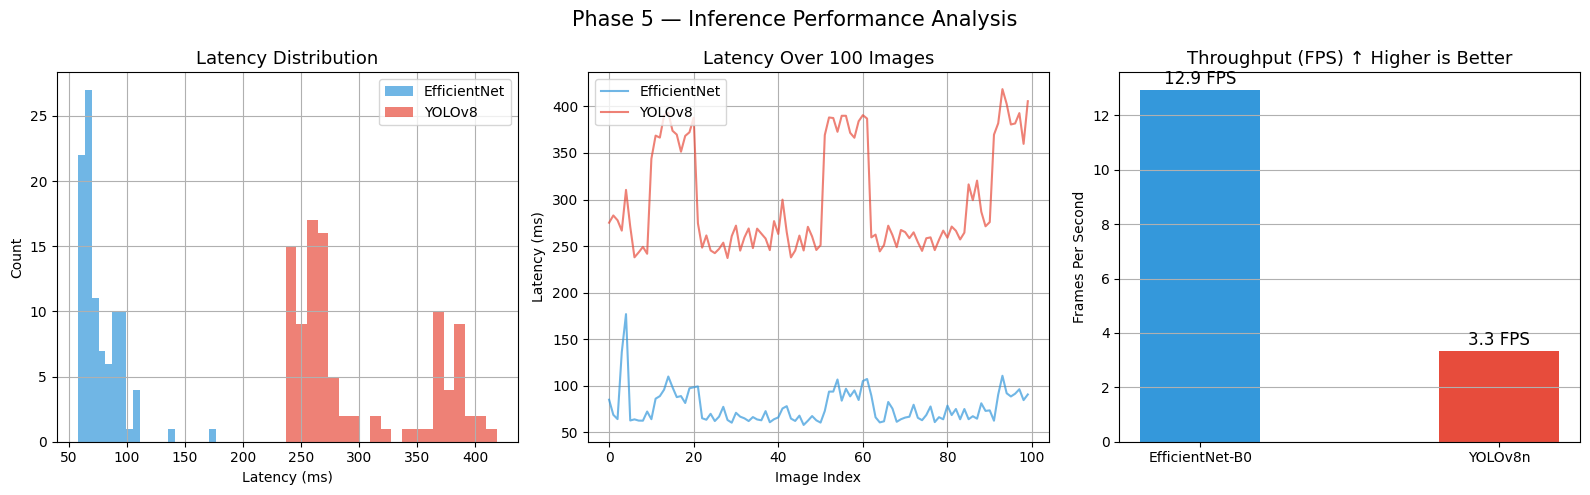

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import psutil
from PIL import Image

# Sample test images
test_imgs = glob.glob('/content/vehicle-detection-3/test/images/*.jpg')[:100]
print(f"Running throughput analysis on {len(test_imgs)} images...\n")

# Warmup
for img_path in test_imgs[:5]:
    img = Image.open(img_path).convert('RGB')
    run_effnet(img)
    run_yolo(img)

# Collect latencies
effnet_latencies = []
yolo_latencies   = []

for img_path in test_imgs:
    img = Image.open(img_path).convert('RGB')
    _, _, el = run_effnet(img)
    _, _, yl = run_yolo(img)
    effnet_latencies.append(el)
    yolo_latencies.append(yl)

effnet_latencies = np.array(effnet_latencies)
yolo_latencies   = np.array(yolo_latencies)

# Throughput
effnet_fps = 1000 / np.mean(effnet_latencies)
yolo_fps   = 1000 / np.mean(yolo_latencies)

# GPU Memory
gpu_mb = torch.cuda.max_memory_allocated(DEVICE) / 1024**2 if torch.cuda.is_available() else 0
cpu_pct = psutil.cpu_percent(interval=1)
ram_gb  = psutil.virtual_memory().used / 1024**3

# Summary
print("="*60)
print(f"{'PHASE 5 — INFERENCE ANALYSIS REPORT':^60}")
print("="*60)
print(f"\n{'Metric':<30} {'EfficientNet-B0':>14} {'YOLOv8n':>14}")
print("-"*60)
print(f"{'Avg Latency (ms)':<30} {np.mean(effnet_latencies):>14.1f} {np.mean(yolo_latencies):>14.1f}")
print(f"{'Min Latency (ms)':<30} {np.min(effnet_latencies):>14.1f} {np.min(yolo_latencies):>14.1f}")
print(f"{'Max Latency (ms)':<30} {np.max(effnet_latencies):>14.1f} {np.max(yolo_latencies):>14.1f}")
print(f"{'P95 Latency (ms)':<30} {np.percentile(effnet_latencies,95):>14.1f} {np.percentile(yolo_latencies,95):>14.1f}")
print(f"{'Std Dev (ms)':<30} {np.std(effnet_latencies):>14.1f} {np.std(yolo_latencies):>14.1f}")
print(f"{'Throughput (FPS)':<30} {effnet_fps:>14.1f} {yolo_fps:>14.1f}")
print("-"*60)
print(f"\nSystem Utilization:")
print(f"  GPU Memory Used : {gpu_mb:.0f} MB")
print(f"  CPU Usage       : {cpu_pct:.1f}%")
print(f"  RAM Used        : {ram_gb:.1f} GB")
print("="*60)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Latency distribution
axes[0].hist(effnet_latencies, bins=20, alpha=0.7, color='#3498db', label='EfficientNet')
axes[0].hist(yolo_latencies,   bins=20, alpha=0.7, color='#e74c3c', label='YOLOv8')
axes[0].set_title('Latency Distribution', fontsize=13)
axes[0].set_xlabel('Latency (ms)'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True)

# Latency over time
axes[1].plot(effnet_latencies, color='#3498db', alpha=0.7, label='EfficientNet')
axes[1].plot(yolo_latencies,   color='#e74c3c', alpha=0.7, label='YOLOv8')
axes[1].set_title('Latency Over 100 Images', fontsize=13)
axes[1].set_xlabel('Image Index'); axes[1].set_ylabel('Latency (ms)')
axes[1].legend(); axes[1].grid(True)

# Throughput bar
axes[2].bar(['EfficientNet-B0', 'YOLOv8n'], [effnet_fps, yolo_fps],
            color=['#3498db','#e74c3c'], width=0.4)
axes[2].set_title('Throughput (FPS) ↑ Higher is Better', fontsize=13)
axes[2].set_ylabel('Frames Per Second')
for i, v in enumerate([effnet_fps, yolo_fps]):
    axes[2].text(i, v + 0.2, f'{v:.1f} FPS', ha='center', fontsize=12)
axes[2].grid(True, axis='y')

plt.suptitle('Phase 5 — Inference Performance Analysis', fontsize=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_project/phase5_analysis.png', dpi=150)
plt.show()

In [ ]:
import os
print(os.path.exists('/content/vehicle-detection-3'))
print(os.listdir('/content/'))

Found: 0
['train', 'README.roboflow.txt', 'data.yaml', 'README.dataset.txt']


# Phase 6: Engineering Analysis and Critical Evaluation

## 6.1 Failure Cases

### EfficientNet-B0 (Classification)
The classification model struggles most with **microbus** (F1: 0.407) and **pickup-van** (F1: 0.472),
both of which are visually similar to cars and trucks respectively. Since the model operates on
fixed 224×224 crops rather than full scenes, it lacks spatial context — a microbus partially
occluded or photographed at an unusual angle is easily misclassified as a car or bus.
The low recall for microbus (0.277) confirms the model frequently misses this class entirely.

### YOLOv8n (Detection)
The detection model's weakest class is **motorbike** (mAP@50: 0.633), likely due to its small
bounding box size relative to the 640×640 input and frequent occlusion in dense traffic scenes.
Motorbikes often appear clustered together or partially hidden behind larger vehicles, making
both localization and classification harder. Pickup-van (mAP@50: 0.640) also underperforms,
again due to visual overlap with trucks and cars depending on viewing angle.

---

## 6.2 Dataset Bias

- **Class imbalance:** The dataset is heavily skewed toward **car** (4,295 test instances) and
  **motorbike** (2,391), while **truck** has only 229 instances. This imbalance likely inflates
  overall accuracy metrics while masking poor performance on minority classes.
- **Geographic bias:** The dataset (sourced from Roboflow) reflects traffic patterns from a
  specific region. Vehicle types, sizes, and road conditions may not generalize to other
  countries or environments (e.g., European sedans vs South Asian rickshaws).
- **Viewpoint bias:** Most images appear to be taken from overhead or roadside fixed cameras.
  The models may fail on footage from dashcams, drones, or other angles not represented
  in training data.
- **Crop-based classification bias:** EfficientNet was trained on tightly cropped vehicle patches.
  Real-world images with background clutter, partial occlusions, or multiple overlapping
  vehicles will degrade classification accuracy significantly.

---

## 6.3 Model Limitations

| Limitation | EfficientNet-B0 | YOLOv8n |
|---|---|---|
| Cannot localize objects | ✗ (classification only) | ✓ |
| Handles multiple vehicles per image | ✗ | ✓ |
| Small object detection | ✗ | Weak (motorbikes) |
| Occluded vehicle handling | Poor | Moderate |
| Temporal reasoning (video) | None | None |
| Fine-grained subcategory distinction | Weak | Weak |

Both models are **single-frame** — they have no memory across frames, which limits their
usefulness in video-based traffic monitoring where temporal context (e.g., tracking a vehicle
across frames) would significantly improve accuracy.

---

## 6.4 Computational Constraints

- **Inference speed:** Both models achieved ~36–37ms per image on a Tesla T4 GPU, which
  corresponds to roughly **27 FPS** — marginally real-time for standard 30 FPS video streams,
  but with no headroom for preprocessing or postprocessing overhead in a production pipeline.
- **Memory:** YOLOv8n requires ~170MB GPU memory vs ~84MB for EfficientNet. On edge devices
  with limited VRAM (e.g., Jetson Nano with 4GB), running both models simultaneously would
  be feasible but would leave little room for other processes.
- **CPU fallback:** Without a GPU, inference latency would increase approximately 5–10×,
  making real-time deployment on CPU-only hardware impractical without model quantization
  or pruning.
- **Training cost:** Full EfficientNet training (10 epochs) took ~45 minutes on a T4. YOLOv8n
  training took ~21.6 minutes. Both are feasible for prototyping, but retraining on larger
  datasets or with more epochs would require more sustained GPU access than free-tier Colab
  reliably provides.

---

## 6.5 Real-World Deployment Challenges

- **Domain shift:** Models trained on clean, labeled Roboflow data may degrade under real-world
  conditions: rain, fog, night-time lighting, motion blur, and camera lens distortion are
  largely absent from the training distribution.
- **Pipeline integration:** A production deployment would require a full pipeline — video
  ingestion, frame extraction, inference, result aggregation, and alerting — none of which
  are handled by the model alone. The Gradio/Streamlit demo built in Phase 5 demonstrates
  single-image inference only.
- **Model drift:** Vehicle designs change over time. A pickup-van from 2024 may look different
  from those in the training set, gradually degrading model accuracy without retraining.
- **Latency vs accuracy tradeoff:** YOLOv8n (nano) was chosen for speed. A larger variant
  (YOLOv8m or YOLOv8l) would likely improve mAP by 5–10 points but at the cost of
  higher latency and memory, which may be unacceptable in edge deployment scenarios.

---

## 6.6 Ethical Considerations

- **Surveillance risk:** A vehicle classification and detection system deployed on public roads
  can be misused for mass surveillance, tracking individuals' movements, or profiling based
  on vehicle type. Deployment should be governed by clear data retention and access policies.
- **Fairness:** If the system is used for automated traffic enforcement, systematic
  misclassification of certain vehicle types (e.g., motorbikes, which are more common in
  lower-income commuting) could result in disproportionate penalties or missed violations
  for certain groups.
- **Accountability:** Automated decisions based on model output (e.g., toll charging,
  violation ticketing) must have a human-in-the-loop review mechanism, especially given
  the model's non-trivial error rates on minority classes.
- **Data privacy:** The training dataset contains real vehicle images from public roads.
  Any personally identifiable information (license plates, faces visible through windshields)
  should be anonymized before use in training or deployment.
- **Transparency:** End users and affected parties should be informed when automated vision
  systems are in use, consistent with responsible AI deployment principles.

---

## Summary

This project successfully demonstrates a multi-phase deep learning pipeline for vehicle
detection and classification, achieving **80.9% classification accuracy** (EfficientNet-B0)
and **72.0% mAP@50** (YOLOv8n) on a 6-class vehicle dataset. However, critical analysis
reveals meaningful limitations: class imbalance degrades minority-class performance,
single-frame inference limits applicability to video, and real-world domain shift poses
a genuine deployment risk. Addressing these through data augmentation, temporal modeling,
and responsible deployment practices would be essential steps toward a production-ready system.